In [1]:
#
# How to use your trained model - Deep Learning basics with Python, TensorFlow and Keras
# Steg 5 - Fyra lagers CNN modell där nod-antalet varierar mellan lagerna 
#

In [2]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
# more info on callbakcs: https://keras.io/callbacks/ model saver is cool too.
from tensorflow.keras.callbacks import TensorBoard
import tensorflow as tf
import pickle
import time


In [3]:
#
# Läser in tidigare sparat data från disk 

DATADIR = "C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\"  # path till katalog med djurbilder
DATADIR_MOD = DATADIR                                 # path till sparad modell

TxT_INPmod_fileN = DATADIR_MOD + "X_train.pickle"     # Filnamn indata
TxT_OUTmod_fileN = DATADIR_MOD + "y_train.pickle"     # Filnamn utdata

print(f"  {TxT_INPmod_fileN  =  }")
print(f"  {TxT_OUTmod_fileN  =  }")

pickle_in = open(TxT_INPmod_fileN,"rb")               # Läs Indata - bildmatrl
X_train = pickle.load(pickle_in)

pickle_in = open(TxT_OUTmod_fileN,"rb")               # Läs Utdata - (0/1) (katt/hund)
y_train = pickle.load(pickle_in)

X_train = X_train/255.0                               # Normera gråskallenivå, (0,255) transformeras till (0,1), utan medlevärdesförskjutning


  TxT_INPmod_fileN  =  'C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\X_train.pickle'
  TxT_OUTmod_fileN  =  'C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\y_train.pickle'


In [26]:
#
# Optimering map densitet, storlek och conv
#

epochs_numb = 30
TxT_NAME = "theOPT_"              # Inledning på logg-fil-namnet
TxT_LOG_DIR = "log_steg5"         # Path till logg-fil


TxT_MODEL_fName = DATADIR_MOD + 'step5-CNN.keras'    # Färdig anpassad modell
print(f"  {TxT_MODEL_fName  =  }")



  TxT_MODEL_fName  =  'C:\\LTH_data\\photo\\PythUtbPic\\SKARP\\step5-CNN.keras'


In [18]:
# Nu - raka rör - ingen Snurra via for-satser


# stepp 5 - Bygg modell
model = Sequential()

model.add(Conv2D(32, (3, 3), input_shape=X_train.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))                # Djupare CNN-arkitektur, fler lager
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3)))                # Djupare CNN-arkitektur, 3rd
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(256, (3, 3)))               # Djupare CNN-arkitektur, 4th
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128))         # Lägg till ett Dense lager med 128 st neuroner, fullt klopplade Upp/Ned
model.add(Activation('relu')) # Rectified Linear Unit
#model.add(Dropout(0.2))       # droppa 20% av neuronerna för att förhindra överträning (overfitting)

model.add(Dense(64))          # Ytterligare dense lager - 2nd
model.add(Activation('relu'))
model.add(Dropout(0.2))
model.add(Dense(1))
model.add(Activation('sigmoid'))


# stepp 6 - Kompilera modellen
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


# stepp 7 - Skapa Loggning
named_tuple = time.localtime() # get struct_time
time_string = time.strftime("%Y%m%d-%H%M", named_tuple) # läsbart format
TxT_LOGG_fNAME = "CNN-{}".format(time_string)
TxT_LOGG_fNAME = "{}model-{}".format(TxT_NAME, TxT_LOGG_fNAME)
print(f" {TxT_LOGG_fNAME = }")

TxT_LOG_DIR_and_fNAME = "{}/{}".format(TxT_LOG_DIR, TxT_LOGG_fNAME)
print(f" {TxT_LOG_DIR_and_fNAME = }")
tensorboard = TensorBoard(log_dir=TxT_LOG_DIR_and_fNAME)


# stepp 8 - Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)


# stepp 9 - Träna modellen
model.fit(X_train, y_train,
          batch_size=32,
          epochs=epochs_numb,
          validation_split=0.3,
          callbacks=[tensorboard, early_stopping])


# Samtidigt som modellen tränas
# Starta en CMD från samma path som detta --> C:\Users\larth\PythUtb\InlUppg_2\SKARP\Cats_and_Dogs>
# Kör från CMD --> kör kommandot: tensorboard --logdir='log_steg5'
# Kör från web browser --> http://localhost:6006/




 TxT_LOGG_fNAME = 'theOPT_model-CNN-20250523-1200'
 TxT_LOG_DIR_and_fNAME = 'log_steg5/theOPT_model-CNN-20250523-1200'
Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.5877 - loss: 0.6524 - val_accuracy: 0.8022 - val_loss: 0.4182
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.8239 - loss: 0.3982 - val_accuracy: 0.8468 - val_loss: 0.3461
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 23s 105ms/step - accuracy: 0.8546 - loss: 0.3323 - val_accuracy: 0.8242 - val_loss: 0.3680
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.8783 - loss: 0.2851 - val_accuracy: 0.8797 - val_loss: 0.2692
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - accuracy: 0.9170 - loss: 0.2077 - val_accuracy: 0.8736 - val_loss: 0.2889
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.9282 - loss: 0.1755 - val_accuracy: 0.8719 - val_loss: 0.2801
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 17s 100ms/step - accuracy: 0.9373 - loss: 0.1498 - val_acc

In [28]:
# Spara modellen som en '.keras'-fil för framtida behov

#model.save(TxT_MODEL_fName)     # Sparar Modellen som ska användas för framtida TEST-prediktion


In [20]:


#####################################################################
# Visualisera med feature maps
# Inför funktionen "visualisera_feature_maps()"


import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


def visualize_feature_maps(model, image, layer_limit=None):
    """
    Visualiserar feature maps från alla Conv2D-lager i modellen för en given bild.

    Parametrar:
    - model: Tränad Keras Sequential-modell med Conv2D-lager.
    - image: En bild med shape (28,28,1) eller (1,28,28,1).
    - layer_limit: (valfritt) Begränsar hur många Conv2D-lager som visualiseras.
    """
    # Se till att bilden har rätt batch-dimension
    if image.ndim == 3:
        img_input = np.expand_dims(image, axis=0)
    else:
        img_input = image

    # Hämta utgångar från alla Conv2D-lager
    conv_layers = [layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D)]
    if layer_limit:
        conv_layers = conv_layers[:layer_limit]

    layer_outputs = [layer.output for layer in conv_layers]
    layer_names = [layer.name for layer in conv_layers]

    # Skapa modell som ger tillgång till mellanliggande aktiveringar
    activation_model = tf.keras.models.Model(inputs=model.layers[0].input, outputs=layer_outputs)

    # Få aktiveringar från bilden
    activations = activation_model.predict(img_input)

    # Visualisera varje lager
    for layer_name, layer_activation in zip(layer_names, activations):
        n_features = layer_activation.shape[-1]  # antal feature maps
        size = layer_activation.shape[1]         # höjd/bredd på varje map

        n_cols = min(n_features, 20)  # visa max 20 kolumner eller minsta antalet filter per lager
        display_grid = np.zeros((size, n_cols * size))

        for col in range(n_cols):
            channel_image = layer_activation[0, :, :, col]
            channel_image -= channel_image.mean()
            channel_image /= (channel_image.std() + 1e-5)
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[:, col * size : (col + 1) * size] = channel_image

        scale = 1. / size
        plt.figure(figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0]))
        plt.title(f"Feature maps from layer: {layer_name}")
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')
        plt.axis('off')
        plt.show()



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


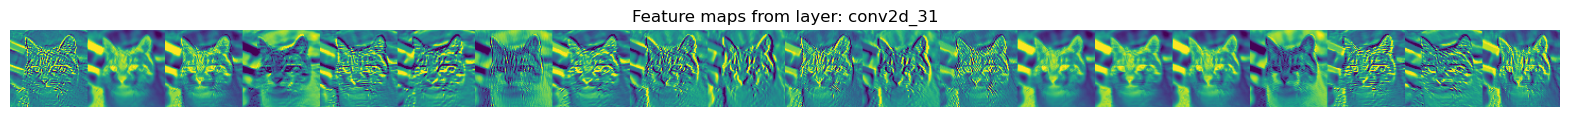

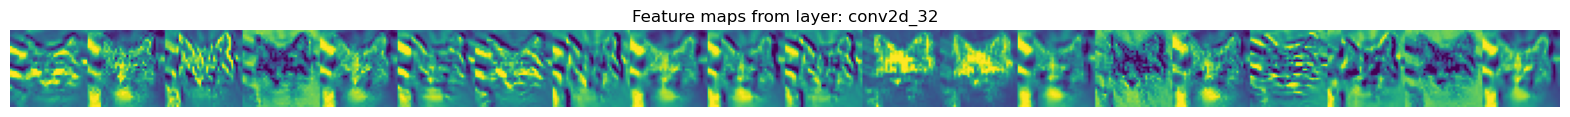

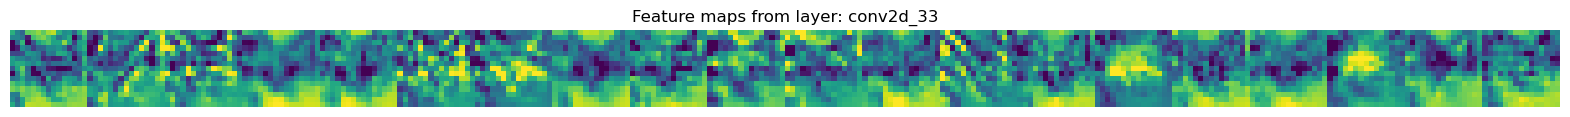

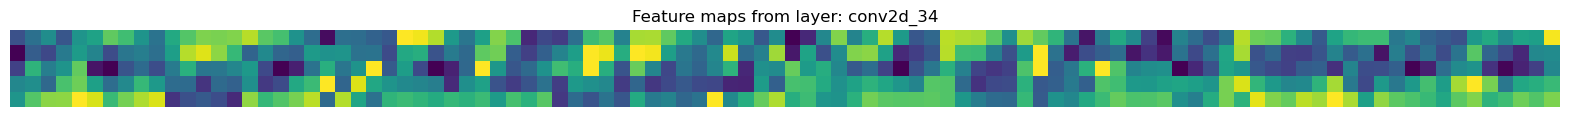

In [30]:
# Välj en katt-bild från testmängden
sample_img = X_train[0]

# Visualisera aktiveringar
visualize_feature_maps(model, sample_img)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


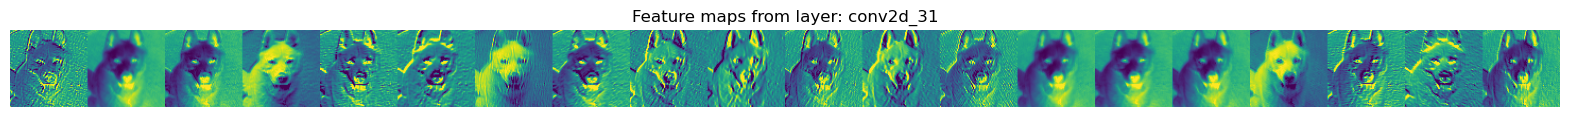

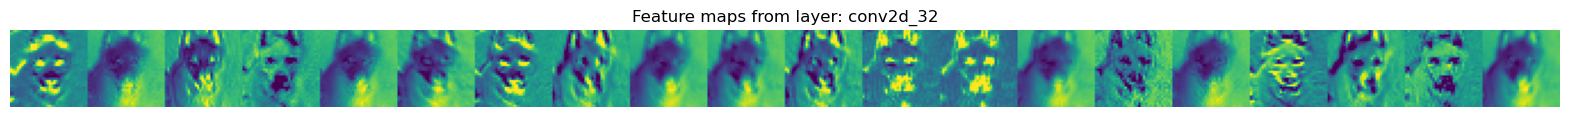

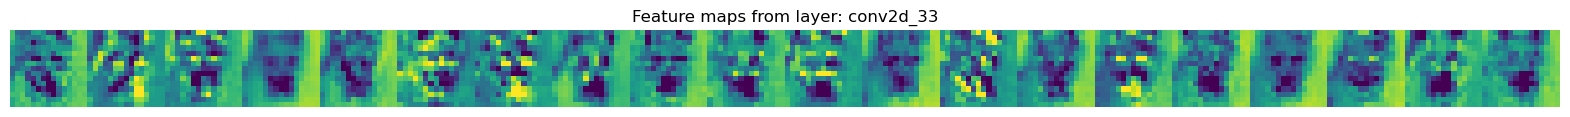

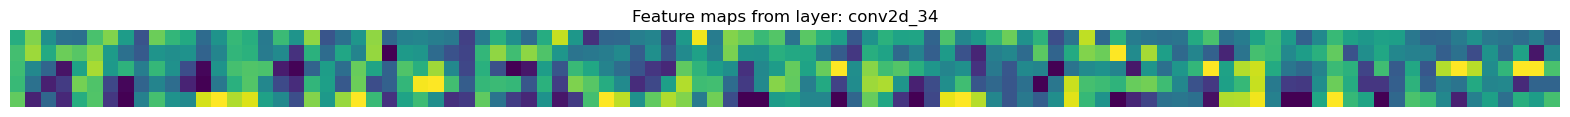

In [32]:
# Välj en hund-bild från testmängden
sample_img = X_train[1]

# Visualisera aktiveringar
visualize_feature_maps(model, sample_img)